In [14]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/Dataset for Data Analytics - Sheet1.csv")

print("Shape:", df.shape)
print("\nColumns:\n")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())

Shape: (1200, 14)

Columns:

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

First 5 Rows:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB
None


In [3]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df))*100
})

missing = missing.sort_values(
    by="Missing %",
    ascending=False
)

missing.head(20)

,Missing Count,Missing %
CouponCode,309,25.75
OrderID,0,0.00
CustomerID,0,0.00
Product,0,0.00
Quantity,0,0.00
Date,0,0.00
UnitPrice,0,0.00
ShippingAddress,0,0.00
OrderStatus,0,0.00
PaymentMethod,0,0.00


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,1200.0,2.945833,1.407557,1.00,2.0000,3.000,4.000,5.00
UnitPrice,1200.0,356.412750,197.177146,11.39,186.0625,364.210,521.570,699.93
ItemsInCart,1200.0,5.485000,2.281983,1.00,4.0000,5.000,7.000,10.00
TotalPrice,1200.0,1053.968300,819.856558,11.39,410.5200,823.615,1578.475,3456.40


In [5]:
numerical_cols = df.select_dtypes(
    include=np.number
).columns

print("Numerical Columns:")
print(numerical_cols)

Numerical Columns:
Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice'], dtype='object')


In [6]:
outlier_summary = []

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    outlier_summary.append(
        [col, len(outliers)]
    )

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Outlier Count"]
)

outlier_df.sort_values(
    by="Outlier Count",
    ascending=False
)

,Feature,Outlier Count
3,TotalPrice,8
0,Quantity,0
1,UnitPrice,0
2,ItemsInCart,0


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

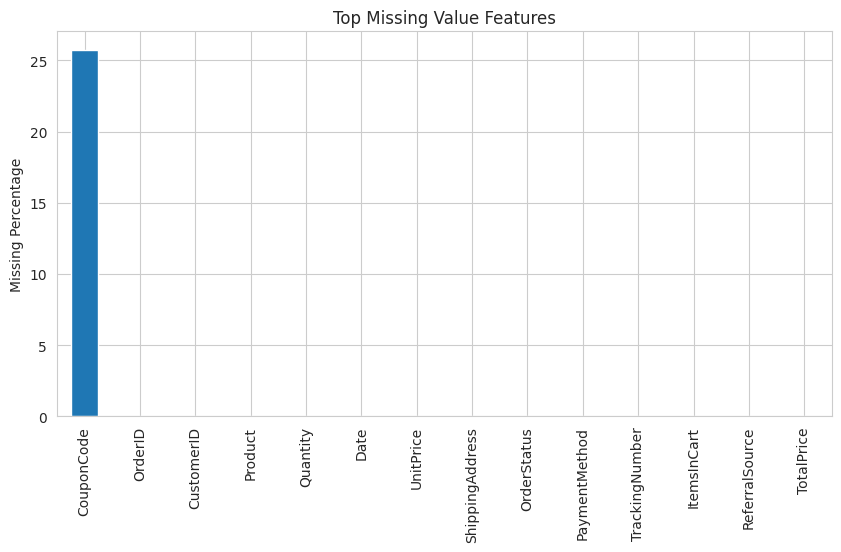

In [8]:
plt.figure(figsize=(10,5))

missing["Missing %"].head(15).plot(
    kind="bar"
)

plt.title("Top Missing Value Features")
plt.ylabel("Missing Percentage")
plt.show()

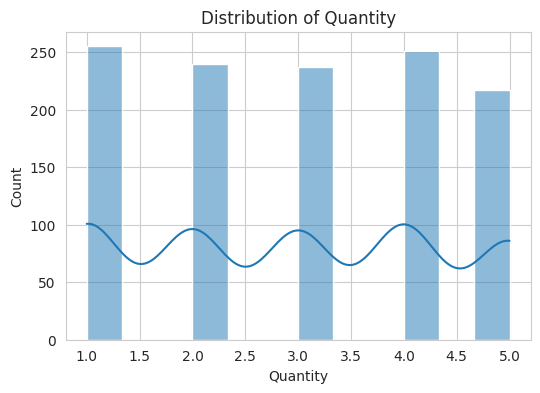

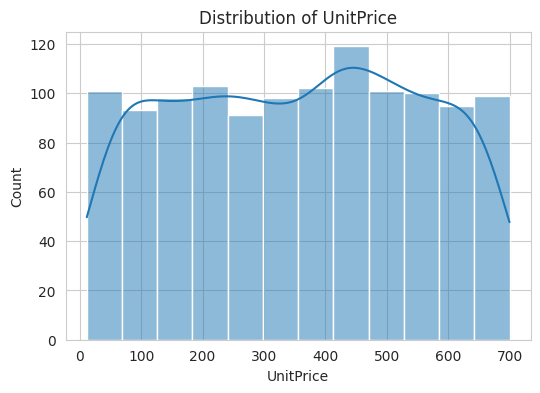

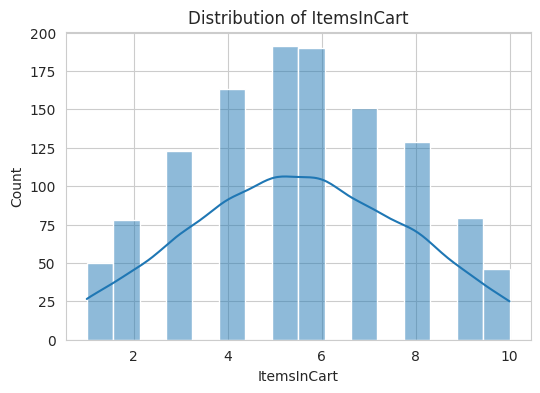

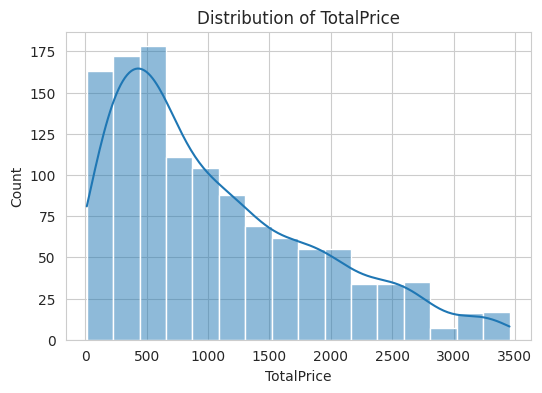

In [9]:
for col in numerical_cols[:5]:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")

    plt.show()

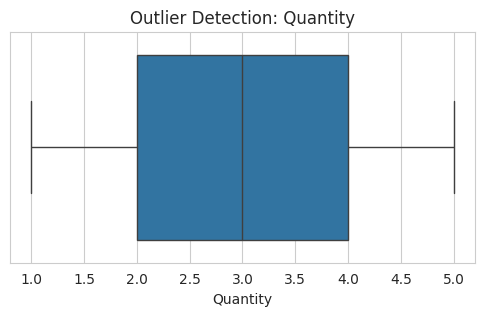

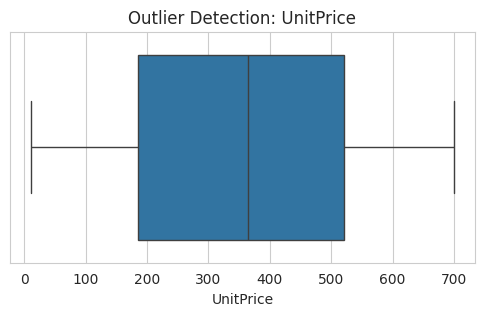

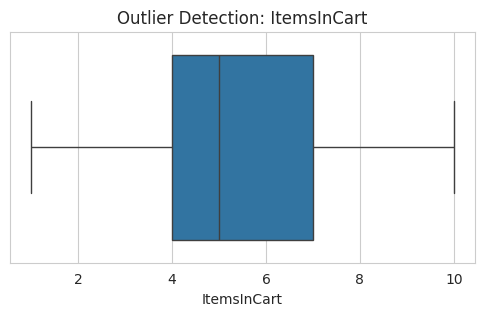

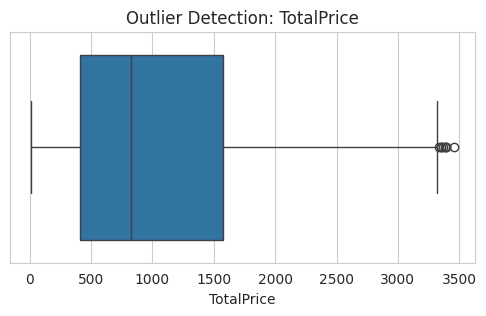

In [10]:
for col in numerical_cols[:5]:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Outlier Detection: {col}")

    plt.show()

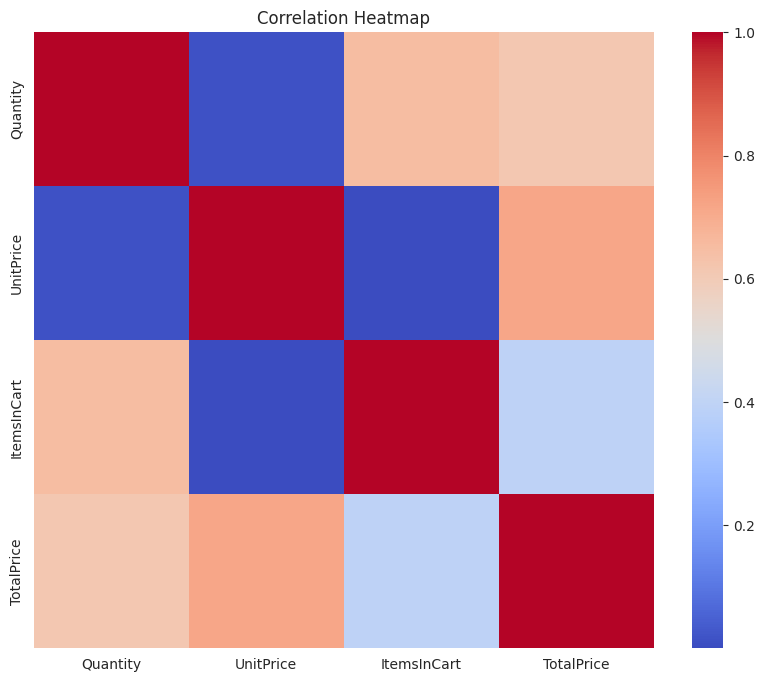

In [11]:
plt.figure(figsize=(10,8))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Key Findings

1. Dataset contains 1,200 rows and 14 columns.

2. Missing values were identified in 1 column (CouponCode), with 309 missing values (25.75%).

3. Several numerical variables exhibit right-skewed distributions, particularly TotalPrice, due to a small number of very high-value transactions.

4. Outliers were detected using the IQR method, particularly in TotalPrice feature (8 outliers identified).

5. Correlation analysis revealed strong relationships between transaction-related variables such as Quantity, UnitPrice, ItemsInCart, and TotalPrice.

6. Data cleaning and feature engineering are required before model development to improve data quality and predictive performance.

# Conclusion

The exploratory data analysis successfully identified the structure, quality, and characteristics of the dataset. Missing values were limited to the CouponCode feature, while numerical analysis revealed outliers in TotalPrice and variations in transaction behavior across customers. The dataset is suitable for further preprocessing, including missing value treatment, outlier handling, and feature engineering. These steps will prepare the data for predictive analytics and machine learning applications in subsequent stages of the project.